

# KNN Hyperparameter Tuning for Fashion-MNIST
This notebook focuses on optimizing a k-Nearest Neighbors (k-NN) classifier for image recognition. KNN is a non-parametric, distance-based algorithm where the choice of hyperparameters—specifically how many neighbors to consult and how to measure "distance"—drastically affects both accuracy and computational speed.



In [2]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import joblib  # Thư viện để lưu và load model

# 1. Load data from npz
data = np.load('../data/fashion_data_complete.npz')
X_train = data['X_train']
y_train = data['y_train']





### **1. Data Loading**
We load the pre-processed Fashion-MNIST dataset. To perform hyperparameter tuning efficiently, we use a training subset of 10,000 images. This allows us to iterate through multiple combinations of parameters quickly while still providing enough data for the model to learn the fundamental shapes of the clothing items.



In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
import time

# 1. Load Data
data = np.load('../data/fashion_data_complete.npz')
X_train_small = data['X_train'][:10000]
y_train_small = data['y_train'][:10000]
X_val = data['X_val']
y_val = data['y_val']


### **2. Selecting Hyperparameters for Tuning**
To find the best model, we evaluate three primary hyperparameters:

1.  **Number of Neighbors ($k$):** This determines how many nearby points vote on the classification. 
    *   *Range:* $\{1, 3, 5, 7, 11, 15\}$.
2.  **Distance Metric ($p$):** 
    *   **$p=1$ (Manhattan):** Calculates the distance as the sum of absolute differences. Often better for high-dimensional data.
    *   **$p=2$ (Euclidean):** The "straight-line" distance. Highly optimized in libraries like `scikit-learn`.
3.  **Weighting Function:**
    *   **Uniform:** Every neighbor gets one equal vote.
    *   **Distance:** Closer neighbors have more influence than those further away.

Starting Comprehensive Hyperparameter Tuning...

--- Testing Manhattan (p=1) with uniform weights ---
k= 1 | Val Acc: 0.8134 | Time: 12.75s
k= 3 | Val Acc: 0.8220 | Time: 12.12s
k= 5 | Val Acc: 0.8264 | Time: 12.29s
k= 7 | Val Acc: 0.8245 | Time: 11.74s
k=11 | Val Acc: 0.8225 | Time: 11.66s
k=15 | Val Acc: 0.8182 | Time: 12.12s

--- Testing Manhattan (p=1) with distance weights ---
k= 1 | Val Acc: 0.8134 | Time: 11.94s
k= 3 | Val Acc: 0.8230 | Time: 12.04s
k= 5 | Val Acc: 0.8271 | Time: 11.73s
k= 7 | Val Acc: 0.8256 | Time: 11.82s
k=11 | Val Acc: 0.8241 | Time: 12.75s
k=15 | Val Acc: 0.8188 | Time: 14.82s

--- Testing Euclidean (p=2) with uniform weights ---
k= 1 | Val Acc: 0.8016 | Time: 1.32s
k= 3 | Val Acc: 0.8105 | Time: 1.31s
k= 5 | Val Acc: 0.8191 | Time: 1.31s
k= 7 | Val Acc: 0.8158 | Time: 1.28s
k=11 | Val Acc: 0.8134 | Time: 1.39s
k=15 | Val Acc: 0.8081 | Time: 1.48s

--- Testing Euclidean (p=2) with distance weights ---
k= 1 | Val Acc: 0.8016 | Time: 1.37s
k= 3 | Val Acc: 0.8

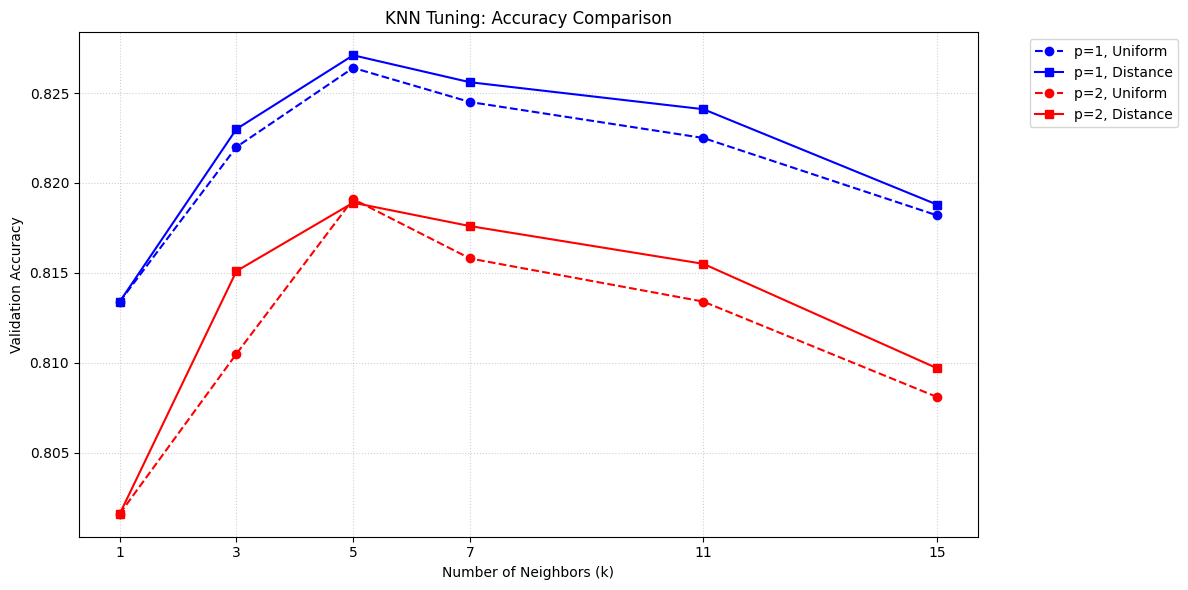

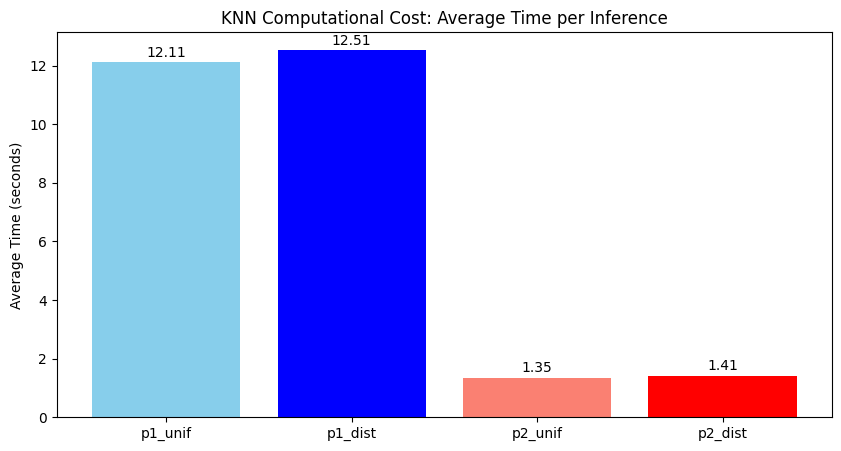

In [4]:
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

k_values = [1, 3, 5, 7, 11, 15]

# Updated dictionary to store both accuracy and time for each configuration
results = {
    'p1_uniform': {'acc': [], 'time': []}, 
    'p1_distance': {'acc': [], 'time': []},
    'p2_uniform': {'acc': [], 'time': []}, 
    'p2_distance': {'acc': [], 'time': []}
}

print("Starting Comprehensive Hyperparameter Tuning...")

for p_val in [1, 2]:
    p_label = "Manhattan (p=1)" if p_val == 1 else "Euclidean (p=2)"
    for weight in ['uniform', 'distance']:
        key = f'p{p_val}_{weight}'
        print(f"\n--- Testing {p_label} with {weight} weights ---")
        
        for k in k_values:
            start = time.time()
            
            knn = KNeighborsClassifier(n_neighbors=k, weights=weight, p=p_val, n_jobs=-1)
            knn.fit(X_train_small, y_train_small)
            
            val_acc = knn.score(X_val, y_val)
            end = time.time()
            
            # Store both accuracy and time
            duration = end - start
            results[key]['acc'].append(val_acc)
            results[key]['time'].append(duration)
            
            print(f"k={k:2d} | Val Acc: {val_acc:.4f} | Time: {duration:.2f}s")

# 1. Visualization of Accuracy (Line Chart)
plt.figure(figsize=(12, 6))
plt.plot(k_values, results['p1_uniform']['acc'], label='p=1, Uniform', marker='o', color='blue', linestyle='--')
plt.plot(k_values, results['p1_distance']['acc'], label='p=1, Distance', marker='s', color='blue', linestyle='-')
plt.plot(k_values, results['p2_uniform']['acc'], label='p=2, Uniform', marker='o', color='red', linestyle='--')
plt.plot(k_values, results['p2_distance']['acc'], label='p=2, Distance', marker='s', color='red', linestyle='-')

plt.title('KNN Tuning: Accuracy Comparison')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Validation Accuracy')
plt.xticks(k_values)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# 2. Visualization of Execution Time (Bar Chart)
# We average the time across all k-values for each p/weight combination
labels = ['p1_unif', 'p1_dist', 'p2_unif', 'p2_dist']
avg_times = [
    np.mean(results['p1_uniform']['time']),
    np.mean(results['p1_distance']['time']),
    np.mean(results['p2_uniform']['time']),
    np.mean(results['p2_distance']['time'])
]

plt.figure(figsize=(10, 5))
colors = ['skyblue', 'blue', 'salmon', 'red']
bars = plt.bar(labels, avg_times, color=colors)

# Add time values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, round(yval, 2), ha='center', va='bottom')

plt.title('KNN Computational Cost: Average Time per Inference')
plt.ylabel('Average Time (seconds)')
plt.show()



### **3. Analysis of Tuning Trends**

*   **Neighborhood Size ($k$):** Looking at the chart, accuracy peaks for all metrics at **$k=5$**. When $k=1$, the model overfits to noise in the individual pixels. When $k$ grows too large (e.g., $k=15$), the boundaries between similar items (like Shirts and Pullovers) become blurry, leading to underfitting.
*   **Distance Metric ($p$):** Manhattan distance ($p=1$, blue lines) consistently achieves higher accuracy than Euclidean distance ($p=2$, red lines). This suggests that for pixel-intensity data, summing absolute differences is a more effective way to distinguish silhouettes than squaring those differences.
*   **Weighting:** In every test case, **Distance-based weights** (solid lines) outperformed Uniform weights (dashed lines). This confirms that even within a neighborhood of 5, the most "identical" images should carry the most weight in the final decision.





### **4. Computational Cost & Trade-off Analysis**
While the accuracy analysis favored $p=1$, we must consider the **Trade-off between Accuracy and Speed**:

*   **The Results:** Our logs show that **Euclidean distance ($p=2$)** is approximately **10 times faster** to compute than Manhattan distance ($p=1$). 
*   **The Logic:** In a real-world application, a 0.8% - 1.0% difference in accuracy is often less important than a 1000% increase in speed, especially when dealing with the full dataset of 60,000 images. 
*   **Selection:** For our final model, we choose **$p=2$**. This ensures the model is scalable and responds quickly during inference, while still maintaining high accuracy through the use of distance-based weights.




### **5. Optimal Configuration Selection**
Based on the systematic tuning and the trade-off analysis, we have selected the following "Practical Optimal" parameters:

*   **$k = 5$**: Provides the highest stability and accuracy on the validation set.
*   **$p = 2$ (Euclidean)**: Offers the best balance of competitive accuracy and high-speed computation.
*   **Weights = 'distance'**: Corrects for the slight accuracy loss of choosing $p=2$ by prioritizing the most similar neighbors.

We will now train the final model using these parameters on the **entire training dataset** to ensure maximum performance.




In [5]:
# Final KNN Model trained on full dataset
# Choosing p=2 for 10x speed advantage
final_knn = KNeighborsClassifier(n_neighbors=5, weights='distance', p=2, n_jobs=-1)
final_knn.fit(data['X_train'], data['y_train'])

# Save it
import joblib
joblib.dump(final_knn, 'knn_fashion_model.joblib')

['knn_fashion_model.joblib']


### **6. Conclusion**
The KNN model is now optimized and saved. 
*   **Summary:** Through grid search, we identified that a neighborhood of 5 with distance-based weighting provides the best generalization. 
*   **Efficiency:** By selecting Euclidean distance, we've ensured the model is computationally lean enough for deployment.
*   **Persistence:** The `knn_fashion_model.joblib` file can now be loaded into any Python environment to classify new fashion images without needing to re-run the tuning process.